# White Wine EDA

In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score , precision_score , recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight

In [2]:
# Data Load

df = pd.read_csv(r"../dataset/winequality-white.csv" , sep = ";")

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [3]:
# Stats

print(df.describe())

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    4898.000000       4898.000000  4898.000000     4898.000000   
mean        6.854788          0.278241     0.334192        6.391415   
std         0.843868          0.100795     0.121020        5.072058   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.300000          0.210000     0.270000        1.700000   
50%         6.800000          0.260000     0.320000        5.200000   
75%         7.300000          0.320000     0.390000        9.900000   
max        14.200000          1.100000     1.660000       65.800000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  4898.000000          4898.000000           4898.000000  4898.000000   
mean      0.045772            35.308085            138.360657     0.994027   
std       0.021848            17.007137             42.498065     0.002991   
min       0.009000             2.000000         

In [5]:
# Null Values

print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [7]:
# Outlier

for col in df.select_dtypes(include='number').columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}: {(outliers / df.shape[0]) * 100}")

fixed acidity: 2.4295630869742753
volatile acidity: 3.79746835443038
citric acid: 5.512454062882809
residual sugar: 0.14291547570436913
chlorides: 4.246631278072683
free sulfur dioxide: 1.0208248264597795
total sulfur dioxide: 0.38791343405471623
density: 0.10208248264597795
pH: 1.5312372396896692
sulphates: 2.5316455696202533
alcohol: 0.0
quality: 4.083299305839118


In [6]:
# Duplicate

d = df.duplicated().sum()

p = ((d / df.shape[0]) * 100).round(2)

print(f"Count = {d} , Percent = {p} %")

Count = 937 , Percent = 19.13 %


# There are 19.13 % of the rows which are duplicated

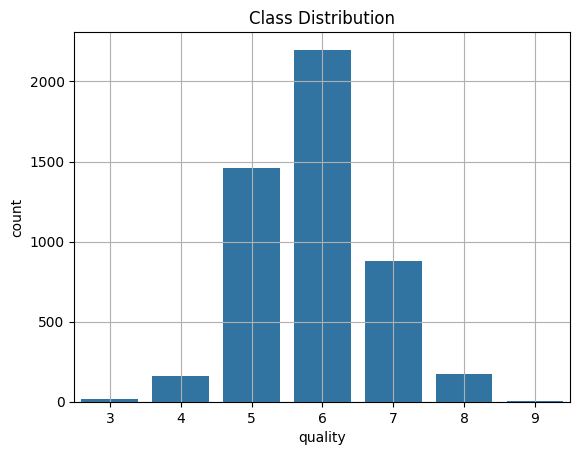

In [5]:
 # Class Distribution

sns.countplot(
    x = "quality" ,
    data = df
)

plt.title("Class Distribution")
plt.grid()
plt.show()

# Highly Imbalanced

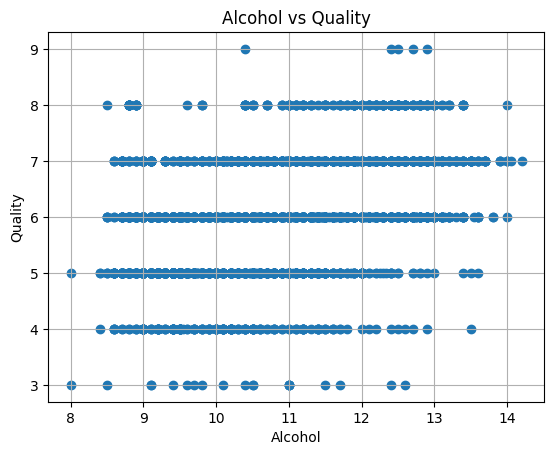

In [6]:
# Alcohol vs Quality

plt.scatter(
    x = df["alcohol"] ,
    y = df["quality"]
)
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Alcohol vs Quality")
plt.grid()
plt.show()

# There is no such direct relation between Alcohol and Quality

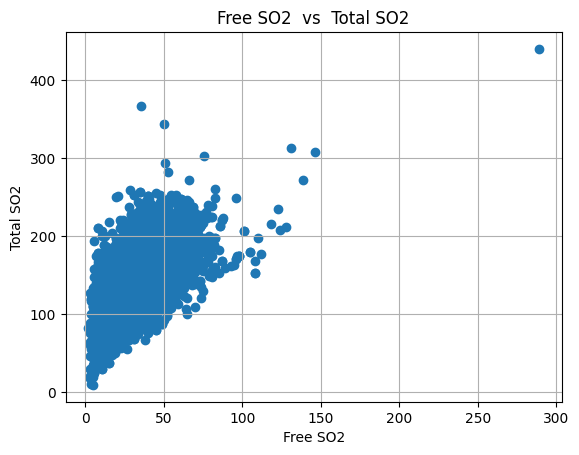

In [7]:
# Free SO2 vs Total SO2

plt.scatter(
    x = df["free sulfur dioxide"] ,
    y = df["total sulfur dioxide"]
)
plt.xlabel("Free SO2")
plt.ylabel("Total SO2")
plt.title("Free SO2  vs  Total SO2")
plt.grid()
plt.show()

# Most of the data points shows the direct relation , that is total S02 is increasing with free SO2.

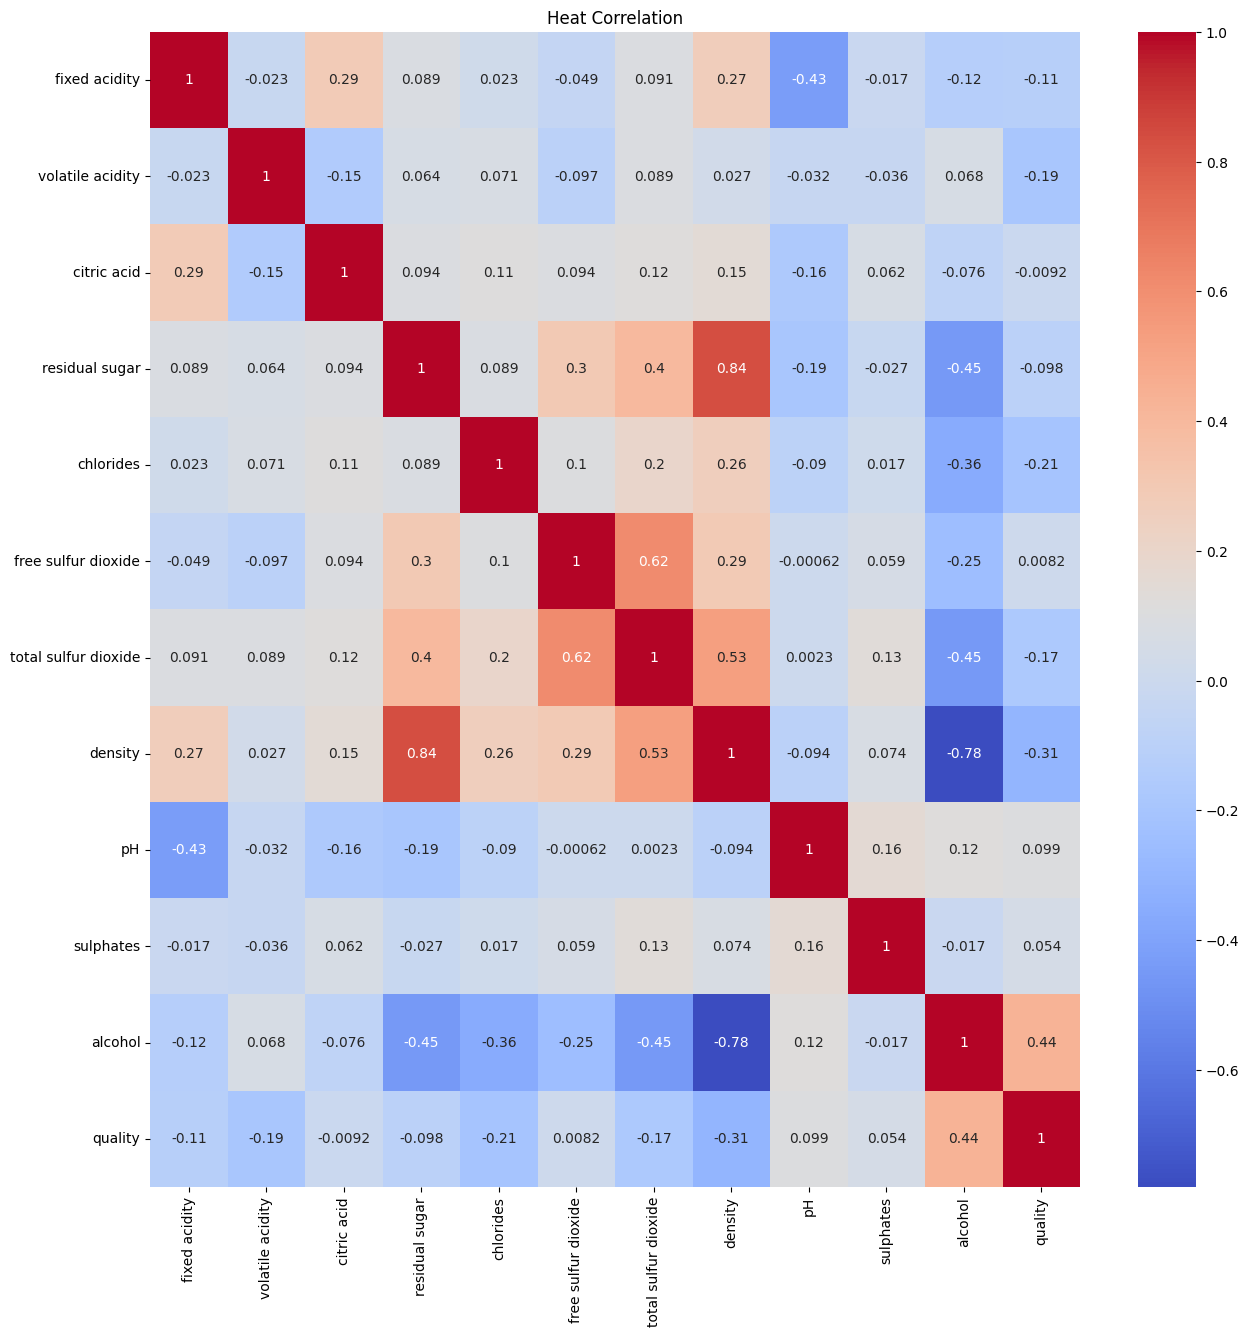

In [8]:
# Heat Map

plt.figure(figsize = (15 , 15))

sns.heatmap(
    df.corr(numeric_only = True) ,
    annot = True , 
    cmap = "coolwarm"
)

plt.title("Heat Correlation")
plt.show()

In [12]:
# Feature Importance (Base Model)

X = df.drop(["quality"] , axis = 1)
y = df["quality"]

X_train , X_test , y_train , y_test = train_test_split(
    X ,
    y ,
    test_size = 0.2 ,
    stratify = y ,
    random_state = 90
)

weight = compute_sample_weight(
    y = y_train ,
    class_weight = "balanced"
)

model = RandomForestClassifier()

model.fit(X_train , y_train , sample_weight = weight)

y_pred = model.predict(X_test)

imp = model.feature_importances_

imp = pd.Series(imp , index = X_train.columns).sort_values(ascending = False)
print(imp)

print()
print(f"F1 Score : {f1_score(y_test , y_pred , average = "weighted")}")
print(f"Precision : {precision_score(y_test , y_pred , average = "weighted")}")
print(f"Recall Score : {recall_score(y_test , y_pred , average = "weighted")}")

alcohol                 0.119357
free sulfur dioxide     0.113510
chlorides               0.101930
fixed acidity           0.100373
total sulfur dioxide    0.096074
density                 0.090984
pH                      0.086269
volatile acidity        0.084104
residual sugar          0.074285
citric acid             0.072683
sulphates               0.060431
dtype: float64

F1 Score : 0.6940275029578961
Precision : 0.7162648472901271
Recall Score : 0.7091836734693877


C:\Users\sailj\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# This warning shows that our model never predict few classes because dataset is higly imbalanced

# Alcohol is the most important feature in this dataset followed by free sulfer dioxide while sulphates is least imp